937 Gebäude in der CSV gefunden.
  Gebäude 243687609: 63,511 kWh (Soll: 63,511 kWh)
  Gebäude 243687615: 60,871 kWh (Soll: 60,871 kWh)
  Gebäude 243687616: 31,330 kWh (Soll: 31,330 kWh)
  Gebäude 243687617: 52,762 kWh (Soll: 52,762 kWh)
  Gebäude 243687618: 35,392 kWh (Soll: 35,392 kWh)
  Gebäude 243687619: 32,914 kWh (Soll: 32,914 kWh)
  Gebäude 243687624: 5,918 kWh (Soll: 5,918 kWh)
  Gebäude 243687625: 28,723 kWh (Soll: 28,723 kWh)
  Gebäude 243687626: 29,702 kWh (Soll: 29,702 kWh)
  Gebäude 243687627: 18,917 kWh (Soll: 18,917 kWh)
  Gebäude 243687628: 35,244 kWh (Soll: 35,244 kWh)
  Gebäude 243687629: 24,348 kWh (Soll: 24,348 kWh)
  Gebäude 243687630: 25,873 kWh (Soll: 25,873 kWh)
  Gebäude 243687631: 50,513 kWh (Soll: 50,513 kWh)
  Gebäude 243687632: 8,658 kWh (Soll: 8,658 kWh)
  Gebäude 243687633: 35,552 kWh (Soll: 35,552 kWh)
  Gebäude 243687634: 35,047 kWh (Soll: 35,047 kWh)
  Gebäude 243687635: 18,081 kWh (Soll: 18,081 kWh)
  Gebäude 243687636: 25,961 kWh (Soll: 25,961 kWh)
  

C:\Users\JONATHANQ\AppData\Local\Temp\ipykernel_22540\1763960121.py:230: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


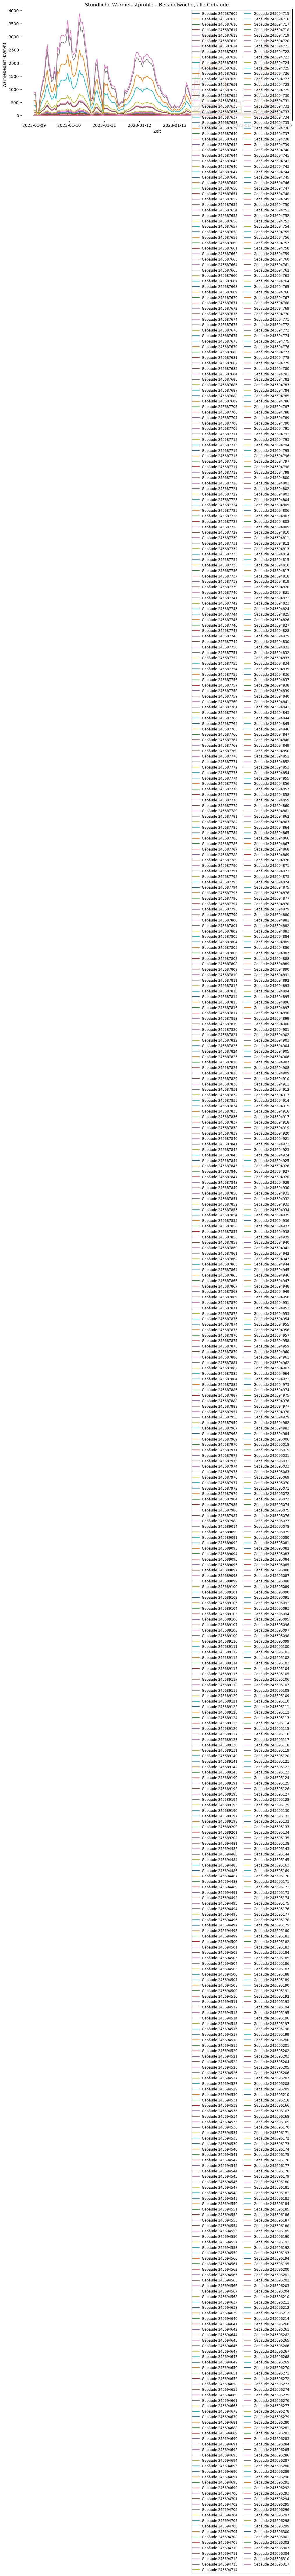

In [ ]:
"""
Berechnung stündlicher Wärmebedarfe aus jährlichen Energiebedarfsdaten.

Zweistufiges Vorgehen (Weg 2):
1. Jahreswärmebedarf mittels Gradtagszahl-Methode auf
   Tageswerte verteilen (Tagesmitteltemperatur verwendet).
2. Jeden Tageswert mit einem typischen Stundenprofil auf 24 Stunden
   herunterbrechen:
     - Raumwärme folgt dem Tagesgang der Außentemperatur (kälter in der
       Nacht/am frühen Morgen -> etwas höherer Bedarf), gedämpft durch
       die thermische Masse des Gebäudes (Glättung).
     - Warmwasser folgt einem typischen Nutzerprofil mit Morgen- und
       Abendspitze (angelehnt an VDI 4655 / BDEW-Profile), statt
       konstant über den Tag verteilt zu sein.

Erweiterbar: Stundenprofile durch reale BDEW-Stundenfaktoren-Tabellen
(z. B. via Bibliothek `demandlib`) oder VDI-4655-Typtage ersetzen, inkl.
Unterscheidung Werktag/Wochenende/Feiertag.
"""

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Konfiguration
# ----------------------------------------------------------------------
CSV_PATH = r"C:\Users\JONATHANQ\Downloads\Gebäude-2981-heat.csv" #Tabelle von greenventory
GEBAEUDE_ID = 243691022
JAHR = 2023
HEIZGRENZTEMPERATUR = 15.0
LAT, LON = 48.4406, 7.9761   # Offenburg

# Glättungsfaktor für den Temperatur-Tagesgang bei der Raumwärme:
# 0 = Raumwärme wird flach (gleichmäßig) auf die Stunden verteilt,
# 1 = Raumwärme folgt 1:1 dem stündlichen Temperaturverlauf.
# Werte um 0.3-0.5 bilden die dämpfende Wirkung der Gebäudemasse ab.
DAEMPFUNG_RAUMWAERME = 0.4


# ----------------------------------------------------------------------
# 2. Gebäudedaten einlesen
# ----------------------------------------------------------------------
def lade_alle_gebaeude(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=";", decimal=",", encoding="utf-8")
    return df
 
 
# ----------------------------------------------------------------------
# 3. Stündliche Wetterdaten via Open-Meteo laden
# ----------------------------------------------------------------------
 
def lade_stundentemperaturen(lat: float, lon: float, jahr: int) -> pd.DataFrame:
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{jahr}-01-01",
        "end_date": f"{jahr}-12-31",
        "hourly": "temperature_2m",
        "timezone": "Europe/Berlin",
    }
    proxies = None
    if HTTP_PROXY or HTTPS_PROXY:
        proxies = {"http": HTTP_PROXY, "https": HTTPS_PROXY}
 
    try:
        r = requests.get(url, params=params, timeout=60, proxies=proxies)
        r.raise_for_status()
    except requests.exceptions.ConnectionError as e:
        raise ConnectionError(
            "Konnte archive-api.open-meteo.com nicht erreichen. "
            "Prüfe: (1) besteht generell Internetzugang von diesem Rechner/Netzwerk, "
            "(2) ist ein Firmen-Proxy nötig (dann HTTP_PROXY/HTTPS_PROXY oben eintragen), "
            "(3) blockiert eine Firewall/DNS diese Domain gezielt. "
            "Alternativ: Wetterdaten manuell im Browser abrufen und als CSV lokal einlesen "
            "(siehe lade_stundentemperaturen_aus_datei())."
        ) from e
 
    data = r.json()["hourly"]
    wetter = pd.DataFrame(
        {"zeitstempel": pd.to_datetime(data["time"]), "temp": data["temperature_2m"]}
    )
    return wetter
 
 
 
# ----------------------------------------------------------------------
# 4. Tageswerte berechnen (Gradtagszahl-Methode, wie im Basisskript)
# ----------------------------------------------------------------------
def berechne_tageswerte(
    wetter_stunden: pd.DataFrame,
    raumwaerme_jahr: float,
    warmwasser_jahr: float,
    heizgrenze: float = HEIZGRENZTEMPERATUR,
) -> pd.DataFrame:
    tage = wetter_stunden.copy()
    tage["datum"] = tage["zeitstempel"].dt.date
    tagesmittel = tage.groupby("datum")["temp"].mean().reset_index()
    tagesmittel.columns = ["datum", "temp_mittel"]
 
    tagesmittel["heizgradtage"] = (heizgrenze - tagesmittel["temp_mittel"]).clip(lower=0)
    summe_hgt = tagesmittel["heizgradtage"].sum()
    if summe_hgt == 0:
        raise ValueError("Summe der Heizgradtage ist 0 – Heizgrenze/Wetterdaten prüfen.")
 
    tagesmittel["raumwaerme_tag_kwh"] = (
        tagesmittel["heizgradtage"] / summe_hgt * raumwaerme_jahr
    )
    tagesmittel["warmwasser_tag_kwh"] = warmwasser_jahr / len(tagesmittel)
 
    return tagesmittel
 
 
# ----------------------------------------------------------------------
# 5. Typisches Warmwasser-Stundenprofil (Morgen-/Abendspitze)
# ----------------------------------------------------------------------
def warmwasser_stundenfaktoren() -> np.ndarray:
    stunden = np.arange(24)
    profil = (
        0.5 * np.exp(-0.5 * ((stunden - 7) / 1.5) ** 2)   # Morgenspitze ~7 Uhr
        + 0.5 * np.exp(-0.5 * ((stunden - 19) / 1.8) ** 2)  # Abendspitze ~19 Uhr
        + 0.05                                             # Grundlast rund um die Uhr
    )
    return profil / profil.sum()   # normieren, Summe = 1
 
 
# ----------------------------------------------------------------------
# 6. Tageswerte auf Stunden disaggregieren
# ----------------------------------------------------------------------
def disaggregiere_auf_stunden(
    wetter_stunden: pd.DataFrame,
    tageswerte: pd.DataFrame,
    daempfung: float = DAEMPFUNG_RAUMWAERME,
) -> pd.DataFrame:
    df = wetter_stunden.copy()
    df["datum"] = df["zeitstempel"].dt.date
    df["stunde"] = df["zeitstempel"].dt.hour
 
    df = df.merge(tageswerte, on="datum", how="left")
 
    # --- Raumwärme: Gewicht je Stunde = Abweichung der Stundentemperatur
    #     vom Tagesmittel (kälter als Mittel -> höherer Bedarf), gedämpft
    #     durch die thermische Masse des Gebäudes (daempfung < 1).
    abweichung = df["temp_mittel"] - df["temp"]          # >0 an kalten Stunden
    df["gewicht_raumwaerme"] = 1.0 + daempfung * abweichung
    df["gewicht_raumwaerme"] = df["gewicht_raumwaerme"].clip(lower=0.05)
 
    # Innerhalb jedes Tages auf Summe 1 normieren, damit die Tagessumme erhalten bleibt
    tages_summe_gewicht = df.groupby("datum")["gewicht_raumwaerme"].transform("sum")
    df["anteil_stunde_raumwaerme"] = df["gewicht_raumwaerme"] / tages_summe_gewicht
    df["raumwaerme_kwh"] = df["anteil_stunde_raumwaerme"] * df["raumwaerme_tag_kwh"]
 
    # --- Warmwasser: festes Tagesprofil mit Morgen-/Abendspitze
    ww_faktoren = warmwasser_stundenfaktoren()
    df["anteil_stunde_warmwasser"] = df["stunde"].map(lambda h: ww_faktoren[h])
    df["warmwasser_kwh"] = df["anteil_stunde_warmwasser"] * df["warmwasser_tag_kwh"]
 
    df["waermebedarf_kwh"] = df["raumwaerme_kwh"] + df["warmwasser_kwh"]
 
    return df[
        ["zeitstempel", "temp", "raumwaerme_kwh", "warmwasser_kwh", "waermebedarf_kwh"]
    ]
 
 
# ----------------------------------------------------------------------
# 7. Hauptprogramm: Schleife über alle Gebäude, gemeinsame Wetterbasis
# ----------------------------------------------------------------------
def main():
    gebaeude_df = lade_alle_gebaeude(CSV_PATH)
    print(f"{len(gebaeude_df)} Gebäude in der CSV gefunden.")
 
    # Wetterdaten nur EINMAL laden – gilt näherungsweise für alle Gebäude
    wetter_stunden = lade_stundentemperaturen(LAT, LON, JAHR)
 
    profile_je_gebaeude = []   # sammelt pro Gebäude eine Spalte (Series)
 
    for _, gebaeude in gebaeude_df.iterrows():
        gebaeude_id = gebaeude["id"]
        raumwaerme_jahr = gebaeude.get("Raumwärmebedarf (kWh/Jahr)")
        warmwasser_jahr = gebaeude.get("Warmwasserbedarf (kWh/Jahr)")
 
        # Gebäude ohne (plausible) Wärmebedarfswerte überspringen
        if pd.isna(raumwaerme_jahr) or pd.isna(warmwasser_jahr):
            print(f"  Gebäude {gebaeude_id}: übersprungen (fehlende Werte).")
            continue
 
        try:
            tageswerte = berechne_tageswerte(
                wetter_stunden, float(raumwaerme_jahr), float(warmwasser_jahr)
            )
            stundenprofil = disaggregiere_auf_stunden(wetter_stunden, tageswerte)
        except ValueError as e:
            print(f"  Gebäude {gebaeude_id}: übersprungen ({e}).")
            continue
 
        # Nur die Ergebnisspalte behalten, mit Zeitstempel als Index
        # und der Gebäude-id als Spaltenname
        serie = stundenprofil.set_index("zeitstempel")["waermebedarf_kwh"]
        serie.name = gebaeude_id
        profile_je_gebaeude.append(serie)
 
        kontrolle = serie.sum()
        erwartet = float(raumwaerme_jahr) + float(warmwasser_jahr)
        print(f"  Gebäude {gebaeude_id}: {kontrolle:,.0f} kWh (Soll: {erwartet:,.0f} kWh)")
 
    # Alle Einzel-Zeitreihen spaltenweise zusammenführen:
    # Index = Zeitstempel, Spalten = Gebäude-id
    gesamtprofil = pd.concat(profile_je_gebaeude, axis=1)
    gesamtprofil.index.name = "zeitstempel"
 
    out_path = "waermebedarf_stundenprofile_alle_gebaeude.csv"
    gesamtprofil.to_csv(out_path, sep=";", decimal=",")
    print(f"\nGesamtprofil gespeichert: {out_path}")
    print(f"Form: {gesamtprofil.shape[0]} Zeitstempel x {gesamtprofil.shape[1]} Gebäude")
 
    # Plot: Beispielwoche im Winter, alle Gebäude übereinander zur Kontrolle
    start = pd.Timestamp(f"{JAHR}-01-09")
    ende = start + pd.Timedelta(days=7)
    woche = gesamtprofil.loc[start:ende]
 
    fig, ax = plt.subplots(figsize=(12, 5))
    for spalte in woche.columns:
        ax.plot(woche.index, woche[spalte], label=f"Gebäude {spalte}")
    ax.set_ylabel("Wärmebedarf (kWh/h)")
    ax.set_xlabel("Zeit")
    ax.legend(loc="upper right", fontsize="small", ncol=2)
    plt.title("Stündliche Wärmelastprofile – Beispielwoche, alle Gebäude")
    plt.tight_layout()
 
 
if __name__ == "__main__":
    main()

In [10]:
Wärmelastkurve=pd.read_csv(r"C:\Users\JONATHANQ\waermebedarf_stundenprofile_alle_gebaeude.csv", decimal=",", sep=";", index_col=0)